In [0]:
VOLUME_PATH = '/Volumes/databricks_milestone/default/hospitalmanagement/'

In [0]:
patients_df = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load(VOLUME_PATH + "patients.csv")

patients_df.show()

+----------+------------+---------+-----------+---+------+----------------+
|patient_id|patient_name|     city|      state|age|gender|insurance_status|
+----------+------------+---------+-----------+---+------+----------------+
|      P101|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active|
|      P102| Priya Reddy|Bangalore|  Karnataka| 29|Female|          Active|
|      P103|  Amit Kumar|   Mumbai|Maharashtra| 42|  Male|        Inactive|
|      P104| Sneha Patel|    Delhi|      Delhi| 31|Female|          Active|
|      P105|  Farhan Ali|  Chennai| Tamil Nadu| 55|  Male|          Active|
|      P106|  Neha Singh|     Pune|Maharashtra| 38|Female|        Inactive|
|      P107| Arjun Verma|Hyderabad|  Telangana| 26|  Male|          Active|
|      P108|  Meera Nair|    Kochi|     Kerala| 48|Female|          Active|
+----------+------------+---------+-----------+---+------+----------------+



In [0]:
doctors_df = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load(VOLUME_PATH + "doctors.csv")

doctors_df.show()

+---------+-----------+-----------+---------+----------------+
|doctor_id|doctor_name| department|     city|consultation_fee|
+---------+-----------+-----------+---------+----------------+
|     D101| Dr. Ramesh| Cardiology|Hyderabad|            1500|
|     D102|  Dr. Priya|  Neurology|Bangalore|            2000|
|     D103|  Dr. Anita|Dermatology|  Chennai|            1000|
|     D104| Dr. Suresh|Orthopedics|   Mumbai|            2500|
|     D105|  Dr. Meera| Pediatrics|    Delhi|            1200|
|     D106|  Dr. Kiran| Cardiology|Hyderabad|            3000|
+---------+-----------+-----------+---------+----------------+



In [0]:
appointments_df = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load(VOLUME_PATH + "appointments.csv")

appointments_df.show()

+--------------+----------+---------+----------------+--------------+-----------+---------+
|appointment_id|patient_id|doctor_id|appointment_date|     diagnosis|bill_amount|   status|
+--------------+----------+---------+----------------+--------------+-----------+---------+
|         A1001|      P101|     D101|      2026-06-01| Heart Checkup|       5000|Completed|
|         A1002|      P102|     D102|      2026-06-01|      Migraine|       3500|Completed|
|         A1003|      P103|     D103|      2026-06-02|  Skin Allergy|       2000|  Pending|
|         A1004|      P104|     D104|      2026-06-02|      Fracture|      12000|Completed|
|         A1005|      P105|     D105|      2026-06-03|         Fever|       1500|Completed|
|         A1006|      P106|     D106|      2026-06-03| Heart Checkup|       7000|Completed|
|         A1007|      P107|     D101|      2026-06-04|    Chest Pain|       5500|Completed|
|         A1008|      P108|     D103|      2026-06-04|Skin Infection|       2500

In [0]:
preferences_df = spark.read.format("json") \
    .option("multiLine", "true") \
    .load(VOLUME_PATH + "/patients_preference.json")

preferences_df.show(truncate=False)

+----------------------------+----------+------------------+
|contact                     |patient_id|preferred_hospital|
+----------------------------+----------+------------------+
|{rahul@mail.com, 9876500011}|P101      |Apollo Hospital   |
|{priya@mail.com, 9876500012}|P102      |Yashoda Hospital  |
|{sneha@mail.com, 9876500014}|P104      |Care Hospital     |
|{meera@mail.com, 9876500018}|P108      |Apollo Hospital   |
+----------------------------+----------+------------------+



In [0]:
patients_df.printSchema()
 
doctors_df.printSchema()
 
appointments_df.printSchema()
 
preferences_df.printSchema()

root
 |-- patient_id: string (nullable = true)
 |-- patient_name: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- insurance_status: string (nullable = true)

root
 |-- doctor_id: string (nullable = true)
 |-- doctor_name: string (nullable = true)
 |-- department: string (nullable = true)
 |-- city: string (nullable = true)
 |-- consultation_fee: integer (nullable = true)

root
 |-- appointment_id: string (nullable = true)
 |-- patient_id: string (nullable = true)
 |-- doctor_id: string (nullable = true)
 |-- appointment_date: date (nullable = true)
 |-- diagnosis: string (nullable = true)
 |-- bill_amount: integer (nullable = true)
 |-- status: string (nullable = true)

root
 |-- contact: struct (nullable = true)
 |    |-- email: string (nullable = true)
 |    |-- phone: string (nullable = true)
 |-- patient_id: string (nullable = true)
 |-- preferred_hospita

In [0]:
patients_df.write.format("delta").mode("overwrite").saveAsTable("bronze_patients")
doctors_df.write.format("delta").mode("overwrite").saveAsTable("bronze_doctors")
appointments_df.write.format("delta").mode("overwrite").saveAsTable("bronze_appointments")
preferences_df.write.format("delta").mode("overwrite").saveAsTable("bronze_patient_preferences")

In [0]:
from pyspark.sql.functions import (
    col, when, lit, to_date, date_format,
    coalesce, month, year, concat
)

patients_clean = patients_df \
    .fillna({"insurance_status": "Unknown", "gender": "Unknown"})
 
doctors_clean = doctors_df \
    .fillna({"consultation_fee": 0})
 
appointments_clean = appointments_df \
    .fillna({"bill_amount": 0, "status": "Unknown"})
 
patients_clean.show()
doctors_clean.show()

+----------+------------+---------+-----------+---+------+----------------+
|patient_id|patient_name|     city|      state|age|gender|insurance_status|
+----------+------------+---------+-----------+---+------+----------------+
|      P101|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active|
|      P102| Priya Reddy|Bangalore|  Karnataka| 29|Female|          Active|
|      P103|  Amit Kumar|   Mumbai|Maharashtra| 42|  Male|        Inactive|
|      P104| Sneha Patel|    Delhi|      Delhi| 31|Female|          Active|
|      P105|  Farhan Ali|  Chennai| Tamil Nadu| 55|  Male|          Active|
|      P106|  Neha Singh|     Pune|Maharashtra| 38|Female|        Inactive|
|      P107| Arjun Verma|Hyderabad|  Telangana| 26|  Male|          Active|
|      P108|  Meera Nair|    Kochi|     Kerala| 48|Female|          Active|
+----------+------------+---------+-----------+---+------+----------------+

+---------+-----------+-----------+---------+----------------+
|doctor_id|doctor_name| 

In [0]:
preferences_flat = preferences_df.select(
    col("patient_id"),
    col("preferred_hospital"),
    col("contact.phone").alias("phone"),
    col("contact.email").alias("email")
)
 
print("Flattened patient_preferences:")
preferences_flat.show(truncate=False)

Flattened patient_preferences:
+----------+------------------+----------+--------------+
|patient_id|preferred_hospital|phone     |email         |
+----------+------------------+----------+--------------+
|P101      |Apollo Hospital   |9876500011|rahul@mail.com|
|P102      |Yashoda Hospital  |9876500012|priya@mail.com|
|P104      |Care Hospital     |9876500014|sneha@mail.com|
|P108      |Apollo Hospital   |9876500018|meera@mail.com|
+----------+------------------+----------+--------------+



In [0]:
patients_with_prefs = patients_clean.join(
    preferences_flat, on="patient_id", how="left"
)
 
print("Patients joined with preferences:")
patients_with_prefs.show(truncate=False)

Patients joined with preferences:
+----------+------------+---------+-----------+---+------+----------------+------------------+----------+--------------+
|patient_id|patient_name|city     |state      |age|gender|insurance_status|preferred_hospital|phone     |email         |
+----------+------------+---------+-----------+---+------+----------------+------------------+----------+--------------+
|P101      |Rahul Sharma|Hyderabad|Telangana  |35 |Male  |Active          |Apollo Hospital   |9876500011|rahul@mail.com|
|P102      |Priya Reddy |Bangalore|Karnataka  |29 |Female|Active          |Yashoda Hospital  |9876500012|priya@mail.com|
|P103      |Amit Kumar  |Mumbai   |Maharashtra|42 |Male  |Inactive        |NULL              |NULL      |NULL          |
|P104      |Sneha Patel |Delhi    |Delhi      |31 |Female|Active          |Care Hospital     |9876500014|sneha@mail.com|
|P105      |Farhan Ali  |Chennai  |Tamil Nadu |55 |Male  |Active          |NULL              |NULL      |NULL          

In [0]:
appt_with_patients = appointments_clean.join(
    patients_clean, on="patient_id", how="left"
)
 
print("Appointments joined with patients:")
appt_with_patients.show()

Appointments joined with patients:
+----------+--------------+---------+----------------+--------------+-----------+---------+------------+---------+-----------+---+------+----------------+
|patient_id|appointment_id|doctor_id|appointment_date|     diagnosis|bill_amount|   status|patient_name|     city|      state|age|gender|insurance_status|
+----------+--------------+---------+----------------+--------------+-----------+---------+------------+---------+-----------+---+------+----------------+
|      P101|         A1001|     D101|      2026-06-01| Heart Checkup|       5000|Completed|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active|
|      P102|         A1002|     D102|      2026-06-01|      Migraine|       3500|Completed| Priya Reddy|Bangalore|  Karnataka| 29|Female|          Active|
|      P103|         A1003|     D103|      2026-06-02|  Skin Allergy|       2000|  Pending|  Amit Kumar|   Mumbai|Maharashtra| 42|  Male|        Inactive|
|      P104|         A1004|     D10

In [0]:
appt_full = appt_with_patients.join(
    doctors_clean.withColumnRenamed("city", "doctor_city"),
    on="doctor_id",
    how="left"
)
 
print("Appointments joined with doctors:")
appt_full.show()

Appointments joined with doctors:
+---------+----------+--------------+----------------+--------------+-----------+---------+------------+---------+-----------+---+------+----------------+-----------+-----------+-----------+----------------+
|doctor_id|patient_id|appointment_id|appointment_date|     diagnosis|bill_amount|   status|patient_name|     city|      state|age|gender|insurance_status|doctor_name| department|doctor_city|consultation_fee|
+---------+----------+--------------+----------------+--------------+-----------+---------+------------+---------+-----------+---+------+----------------+-----------+-----------+-----------+----------------+
|     D101|      P101|         A1001|      2026-06-01| Heart Checkup|       5000|Completed|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active| Dr. Ramesh| Cardiology|  Hyderabad|            1500|
|     D102|      P102|         A1002|      2026-06-01|      Migraine|       3500|Completed| Priya Reddy|Bangalore|  Karnataka| 29|Fema

In [0]:
appt_full = appt_full.withColumn(
    "final_bill",
    col("bill_amount") + col("consultation_fee")
)
 
print("final_bill column added:")
appt_full.select("appointment_id", "bill_amount", "consultation_fee", "final_bill").show()

final_bill column added:
+--------------+-----------+----------------+----------+
|appointment_id|bill_amount|consultation_fee|final_bill|
+--------------+-----------+----------------+----------+
|         A1001|       5000|            1500|      6500|
|         A1002|       3500|            2000|      5500|
|         A1003|       2000|            1000|      3000|
|         A1004|      12000|            2500|     14500|
|         A1005|       1500|            1200|      2700|
|         A1006|       7000|            3000|     10000|
|         A1007|       5500|            1500|      7000|
|         A1008|       2500|            1000|      3500|
|         A1009|       6500|            3000|      9500|
|         A1010|       4500|            2500|      7000|
+--------------+-----------+----------------+----------+



In [0]:
appt_full = appt_full.withColumn(
    "appointment_date", to_date(col("appointment_date"), "yyyy-MM-dd")
).withColumn(
    "appointment_month", date_format(col("appointment_date"), "yyyy-MM")
)
 
print("appointment_month column added:")
appt_full.select("appointment_id", "appointment_date", "appointment_month").show()

appointment_month column added:
+--------------+----------------+-----------------+
|appointment_id|appointment_date|appointment_month|
+--------------+----------------+-----------------+
|         A1001|      2026-06-01|          2026-06|
|         A1002|      2026-06-01|          2026-06|
|         A1003|      2026-06-02|          2026-06|
|         A1004|      2026-06-02|          2026-06|
|         A1005|      2026-06-03|          2026-06|
|         A1006|      2026-06-03|          2026-06|
|         A1007|      2026-06-04|          2026-06|
|         A1008|      2026-06-04|          2026-06|
|         A1009|      2026-06-05|          2026-06|
|         A1010|      2026-06-05|          2026-06|
+--------------+----------------+-----------------+



In [0]:
appt_full = appt_full.withColumn(
    "patient_age_group",
    when(col("age") >= 50, "Senior")
    .when(col("age") >= 30, "Adult")
    .otherwise("Young")
)
 
print("patient_age_group column added:")
appt_full.select("patient_id", "age", "patient_age_group").show()

patient_age_group column added:
+----------+---+-----------------+
|patient_id|age|patient_age_group|
+----------+---+-----------------+
|      P101| 35|            Adult|
|      P102| 29|            Young|
|      P103| 42|            Adult|
|      P104| 31|            Adult|
|      P105| 55|           Senior|
|      P106| 38|            Adult|
|      P107| 26|            Young|
|      P108| 48|            Adult|
|      P101| 35|            Adult|
|      P104| 31|            Adult|
+----------+---+-----------------+



In [0]:
appt_full.write.format("delta").mode("overwrite").saveAsTable("silver_appointments")
patients_with_prefs.write.format("delta").mode("overwrite").saveAsTable("silver_patients")

In [0]:
appt_full.createOrReplaceTempView("vw_appointments")
patients_with_prefs.createOrReplaceTempView("vw_patients")
doctors_clean.createOrReplaceTempView("vw_doctors")
# temp views

In [0]:
spark.sql("""
    SELECT SUM(final_bill) AS total_hospital_revenue
    FROM vw_appointments
    WHERE status = 'Completed'
""").show()

total_hospital_revenue
55700


In [0]:
spark.sql("""
    SELECT department,
           SUM(final_bill) AS revenue_by_department
    FROM vw_appointments
    WHERE status = 'Completed'
    GROUP BY department
    ORDER BY revenue_by_department DESC
""").show()

+-----------+---------------------+
| department|revenue_by_department|
+-----------+---------------------+
| Cardiology|                33000|
|Orthopedics|                14500|
|  Neurology|                 5500|
| Pediatrics|                 2700|
+-----------+---------------------+



In [0]:
spark.sql("""
    SELECT city,
           SUM(final_bill) AS revenue_by_city
    FROM vw_appointments
    WHERE status = 'Completed'
    GROUP BY city
    ORDER BY revenue_by_city DESC
""").show()

+---------+---------------+
|     city|revenue_by_city|
+---------+---------------+
|Hyderabad|          23000|
|    Delhi|          14500|
|     Pune|          10000|
|Bangalore|           5500|
|  Chennai|           2700|
+---------+---------------+



In [0]:
spark.sql("""
    SELECT *
    FROM vw_appointments
    WHERE status = 'Completed'
""").show()

+---------+----------+--------------+----------------+--------------+-----------+---------+------------+---------+-----------+---+------+----------------+-----------+-----------+-----------+----------------+----------+-----------------+-----------------+
|doctor_id|patient_id|appointment_id|appointment_date|     diagnosis|bill_amount|   status|patient_name|     city|      state|age|gender|insurance_status|doctor_name| department|doctor_city|consultation_fee|final_bill|appointment_month|patient_age_group|
+---------+----------+--------------+----------------+--------------+-----------+---------+------------+---------+-----------+---+------+----------------+-----------+-----------+-----------+----------------+----------+-----------------+-----------------+
|     D101|      P101|         A1001|      2026-06-01| Heart Checkup|       5000|Completed|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active| Dr. Ramesh| Cardiology|  Hyderabad|            1500|      6500|          2026-06

In [0]:
spark.sql("""
    SELECT patient_id,
           patient_name,
           SUM(final_bill) AS total_billed
    FROM vw_appointments
    GROUP BY patient_id, patient_name
    ORDER BY total_billed DESC
    LIMIT 5
""").show()

+----------+------------+------------+
|patient_id|patient_name|total_billed|
+----------+------------+------------+
|      P104| Sneha Patel|       21500|
|      P101|Rahul Sharma|       16000|
|      P106|  Neha Singh|       10000|
|      P107| Arjun Verma|        7000|
|      P102| Priya Reddy|        5500|
+----------+------------+------------+



In [0]:
from pyspark.sql.window import Window
from pyspark.sql.functions import *

In [0]:
doctor_revenue = appt_full.groupBy("doctor_id", "doctor_name") \
    .agg(sum("final_bill").alias("total_revenue"))
 
window_doctor = Window.orderBy(col("total_revenue").desc())
 
doctor_ranked = doctor_revenue.withColumn(
    "revenue_rank", dense_rank().over(window_doctor)
)
 
print("Doctors ranked by revenue:")
doctor_ranked.show()

Doctors ranked by revenue:


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+---------+-----------+-------------+------------+
|doctor_id|doctor_name|total_revenue|revenue_rank|
+---------+-----------+-------------+------------+
|     D104| Dr. Suresh|        21500|           1|
|     D106|  Dr. Kiran|        19500|           2|
|     D101| Dr. Ramesh|        13500|           3|
|     D103|  Dr. Anita|         6500|           4|
|     D102|  Dr. Priya|         5500|           5|
|     D105|  Dr. Meera|         2700|           6|
+---------+-----------+-------------+------------+



In [0]:
dept_revenue = appt_full.groupBy("department") \
    .agg(sum("final_bill").alias("total_revenue"))
 
window_dept = Window.orderBy(col("total_revenue").desc())
 
dept_ranked = dept_revenue.withColumn(
    "dept_rank", dense_rank().over(window_dept)
)
 
print("Departments ranked by revenue:")
dept_ranked.show()

Departments ranked by revenue:


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-----------+-------------+---------+
| department|total_revenue|dept_rank|
+-----------+-------------+---------+
| Cardiology|        33000|        1|
|Orthopedics|        21500|        2|
|Dermatology|         6500|        3|
|  Neurology|         5500|        4|
| Pediatrics|         2700|        5|
+-----------+-------------+---------+



In [0]:
patient_billing = appt_full.groupBy("patient_id", "patient_name") \
    .agg(sum("final_bill").alias("total_billed"))
 
window_patient = Window.orderBy(col("total_billed").desc())
 
top3_patients = patient_billing.withColumn(
    "billing_rank", dense_rank().over(window_patient)
).filter(col("billing_rank") <= 3)
 
print("Top 3 patients by billing:")
top3_patients.show()

Top 3 patients by billing:


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+----------+------------+------------+------------+
|patient_id|patient_name|total_billed|billing_rank|
+----------+------------+------------+------------+
|      P104| Sneha Patel|       21500|           1|
|      P101|Rahul Sharma|       16000|           2|
|      P106|  Neha Singh|       10000|           3|
+----------+------------+------------+------------+



In [0]:
doctor_dept_revenue = appt_full.groupBy("department", "doctor_id", "doctor_name") \
    .agg(sum("final_bill").alias("total_revenue"))
 
window_dept_doctor = Window.partitionBy("department").orderBy(col("total_revenue").desc())
 
top_doctor_per_dept = doctor_dept_revenue.withColumn(
    "dept_doctor_rank", row_number().over(window_dept_doctor)
).filter(col("dept_doctor_rank") == 1)
 
print("Top doctor in each department:")
top_doctor_per_dept.show()

Top doctor in each department:
+-----------+---------+-----------+-------------+----------------+
| department|doctor_id|doctor_name|total_revenue|dept_doctor_rank|
+-----------+---------+-----------+-------------+----------------+
| Cardiology|     D106|  Dr. Kiran|        19500|               1|
|Dermatology|     D103|  Dr. Anita|         6500|               1|
|  Neurology|     D102|  Dr. Priya|         5500|               1|
|Orthopedics|     D104| Dr. Suresh|        21500|               1|
| Pediatrics|     D105|  Dr. Meera|         2700|               1|
+-----------+---------+-----------+-------------+----------------+



In [0]:
daily_revenue = appt_full.groupBy("appointment_date") \
    .agg(sum("final_bill").alias("daily_revenue")) \
    .orderBy("appointment_date")
 
window_running = Window.orderBy("appointment_date").rowsBetween(
    Window.unboundedPreceding, Window.currentRow
)
 
running_revenue = daily_revenue.withColumn(
    "running_revenue", sum("daily_revenue").over(window_running)
)
 
print("Running revenue by appointment_date:")
running_revenue.show()

Running revenue by appointment_date:


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+----------------+-------------+---------------+
|appointment_date|daily_revenue|running_revenue|
+----------------+-------------+---------------+
|      2026-06-01|        12000|          12000|
|      2026-06-02|        17500|          29500|
|      2026-06-03|        12700|          42200|
|      2026-06-04|        10500|          52700|
|      2026-06-05|        16500|          69200|
+----------------+-------------+---------------+



In [0]:
appt_full.write.format("delta").mode("overwrite").save(
    "/delta/healthcare/appointments_delta"
)

In [0]:
appt_full.write.format("delta").mode("overwrite").saveAsTable(
    "gold_appointments"
)

In [0]:
spark.sql("""
    CREATE TABLE IF NOT EXISTS gold_doctor_revenue
    USING DELTA
    AS
    SELECT doctor_id, doctor_name, department,
           SUM(final_bill) AS total_revenue
    FROM silver_appointments
    GROUP BY doctor_id, doctor_name, department
""")

DataFrame[num_affected_rows: bigint, num_inserted_rows: bigint]

In [0]:
spark.sql("DESCRIBE HISTORY gold_appointments").show()

+-------+-------------------+---------------+--------------------+--------------------+--------------------+----+-----------------+-----------------------+--------------------+-----------+-----------------+-------------+--------------------+------------+--------------------+
|version|          timestamp|         userId|            userName|           operation| operationParameters| job|         notebook|queryHistoryStatementId|           clusterId|readVersion|   isolationLevel|isBlindAppend|    operationMetrics|userMetadata|          engineInfo|
+-------+-------------------+---------------+--------------------+--------------------+--------------------+----+-----------------+-----------------------+--------------------+-----------+-----------------+-------------+--------------------+------------+--------------------+
|      0|2026-06-22 10:35:51|148655192397593|azuser7230_mml.lo...|CREATE OR REPLACE...|{isV1SaveAsTableO...|NULL|{490106471942203}|   3f3b0d4f-40d9-4d2...|0622-101327-jooa2

In [0]:
df_version_0 = spark.read.format("delta") \
    .option("versionAsOf", 0) \
    .table("gold_appointments")
 
print("Time Travel - Version 0:")
df_version_0.show()

Time Travel - Version 0:
+---------+----------+--------------+----------------+--------------+-----------+---------+------------+---------+-----------+---+------+----------------+-----------+-----------+-----------+----------------+----------+-----------------+-----------------+
|doctor_id|patient_id|appointment_id|appointment_date|     diagnosis|bill_amount|   status|patient_name|     city|      state|age|gender|insurance_status|doctor_name| department|doctor_city|consultation_fee|final_bill|appointment_month|patient_age_group|
+---------+----------+--------------+----------------+--------------+-----------+---------+------------+---------+-----------+---+------+----------------+-----------+-----------+-----------+----------------+----------+-----------------+-----------------+
|     D101|      P101|         A1001|      2026-06-01| Heart Checkup|       5000|Completed|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active| Dr. Ramesh| Cardiology|  Hyderabad|            1500|   

In [0]:
from delta.tables import DeltaTable
 
updated_patients_data = [
    ("P101", "Pune", "Active"),
    ("P103", "Mumbai", "Active"),   
    ("P106", "Bangalore", "Active") 
]
 
updated_patients_df = spark.createDataFrame(
    updated_patients_data,
    ["patient_id", "city", "insurance_status"]
)

In [0]:
delta_patients = DeltaTable.forName(spark, "silver_patients")
 
delta_patients.alias("target").merge(
    updated_patients_df.alias("source"),
    "target.patient_id = source.patient_id"
).whenMatchedUpdate(set={
    "city": "source.city",
    "insurance_status": "source.insurance_status"
}).execute()
 
print("SCD Type 1 merge completed.")

SCD Type 1 merge completed.


In [0]:
spark.sql("DESCRIBE HISTORY silver_patients").show(5, truncate=False)

+-------+-------------------+---------------+-------------------------------------------------------+---------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----+-----------------+------------------------------------+------------------------+-----------+-----------------+-------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [0]:
spark.sql("OPTIMIZE gold_appointments")


DataFrame[path: string, metrics: struct<numFilesAdded:bigint,numFilesRemoved:bigint,filesAdded:struct<min:bigint,max:bigint,avg:double,totalFiles:bigint,totalSize:bigint>,filesRemoved:struct<min:bigint,max:bigint,avg:double,totalFiles:bigint,totalSize:bigint>,partitionsOptimized:bigint,zOrderStats:struct<strategyName:string,inputCubeFiles:struct<num:bigint,size:bigint>,inputOtherFiles:struct<num:bigint,size:bigint>,inputNumCubes:bigint,mergedFiles:struct<num:bigint,size:bigint>,numOutputCubes:bigint,mergedNumCubes:bigint>,clusteringStats:struct<inputZCubeFiles:struct<numFiles:bigint,size:bigint>,inputOtherFiles:struct<numFiles:bigint,size:bigint>,inputNumZCubes:bigint,mergedFiles:struct<numFiles:bigint,size:bigint>,numOutputZCubes:bigint>,numBins:bigint,numBatches:bigint,totalConsideredFiles:bigint,totalFilesSkipped:bigint,preserveInsertionOrder:boolean,numFilesSkippedToReduceWriteAmplification:bigint,numBytesSkippedToReduceWriteAmplification:bigint,startTimeMs:bigint,endTimeMs:bigint,

In [0]:
spark.sql("OPTIMIZE gold_appointments ZORDER BY (patient_id)")


DataFrame[path: string, metrics: struct<numFilesAdded:bigint,numFilesRemoved:bigint,filesAdded:struct<min:bigint,max:bigint,avg:double,totalFiles:bigint,totalSize:bigint>,filesRemoved:struct<min:bigint,max:bigint,avg:double,totalFiles:bigint,totalSize:bigint>,partitionsOptimized:bigint,zOrderStats:struct<strategyName:string,inputCubeFiles:struct<num:bigint,size:bigint>,inputOtherFiles:struct<num:bigint,size:bigint>,inputNumCubes:bigint,mergedFiles:struct<num:bigint,size:bigint>,numOutputCubes:bigint,mergedNumCubes:bigint>,clusteringStats:struct<inputZCubeFiles:struct<numFiles:bigint,size:bigint>,inputOtherFiles:struct<numFiles:bigint,size:bigint>,inputNumZCubes:bigint,mergedFiles:struct<numFiles:bigint,size:bigint>,numOutputZCubes:bigint>,numBins:bigint,numBatches:bigint,totalConsideredFiles:bigint,totalFilesSkipped:bigint,preserveInsertionOrder:boolean,numFilesSkippedToReduceWriteAmplification:bigint,numBytesSkippedToReduceWriteAmplification:bigint,startTimeMs:bigint,endTimeMs:bigint,

In [0]:
spark.sql("VACUUM gold_appointments RETAIN 168 HOURS")


DataFrame[path: string]

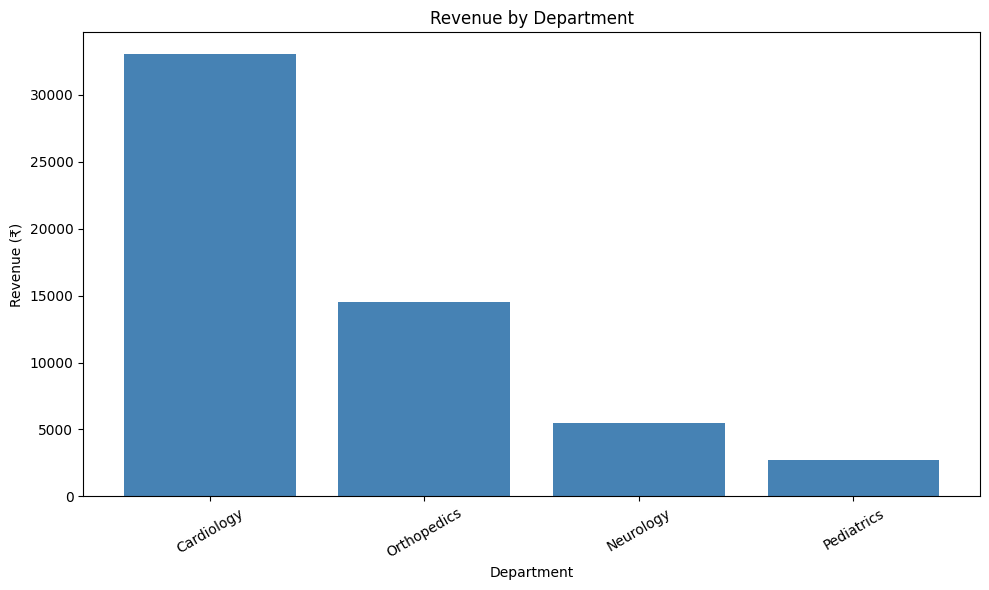

In [0]:
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql.functions import col, sum


 
matplotlib.use("Agg") 
dept_rev_pd = appt_full.filter(col("status") == "Completed") \
    .groupBy("department") \
    .agg(sum("final_bill").alias("revenue")) \
    .toPandas() \
    .sort_values("revenue", ascending=False)
 
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(dept_rev_pd["department"], dept_rev_pd["revenue"], color="steelblue")
ax.set_title("Revenue by Department")
ax.set_xlabel("Department")
ax.set_ylabel("Revenue (₹)")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("/tmp/revenue_by_department.png")
display(fig)
plt.close()

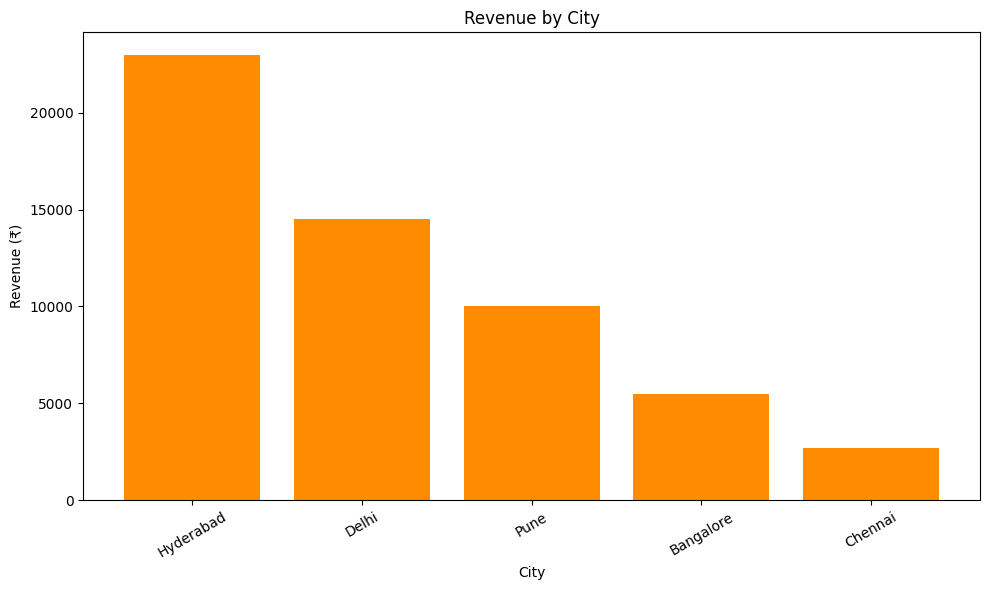

In [0]:
city_rev_pd = appt_full.filter(col("status") == "Completed") \
    .groupBy("city") \
    .agg(sum("final_bill").alias("revenue")) \
    .toPandas() \
    .sort_values("revenue", ascending=False)
 
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(city_rev_pd["city"], city_rev_pd["revenue"], color="darkorange")
ax.set_title("Revenue by City")
ax.set_xlabel("City")
ax.set_ylabel("Revenue (₹)")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("/tmp/revenue_by_city.png")
display(fig)
plt.close()

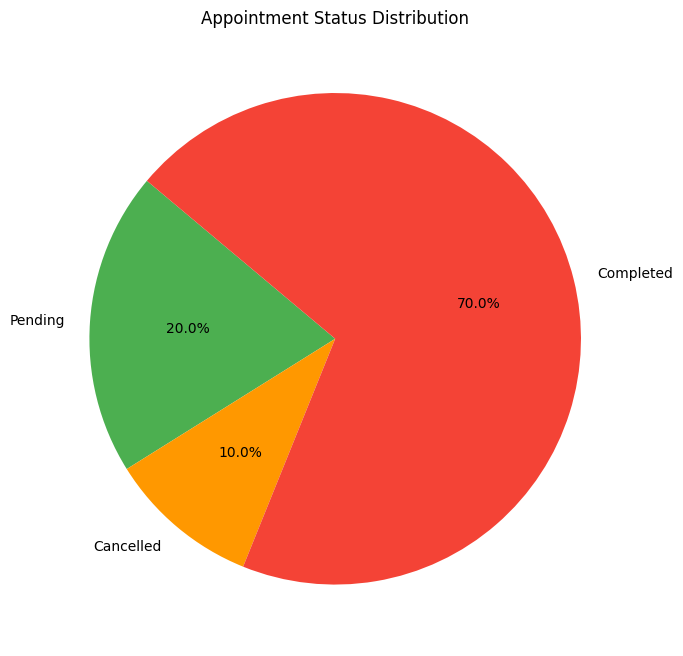

In [0]:
status_pd = appt_full.groupBy("status") \
    .count() \
    .toPandas()
 
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    status_pd["count"],
    labels=status_pd["status"],
    autopct="%1.1f%%",
    startangle=140,
    colors=["#4CAF50", "#FF9800", "#F44336"]
)
ax.set_title("Appointment Status Distribution")
plt.tight_layout()
plt.savefig("/tmp/appointment_status_pie.png")
display(fig)
plt.close()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


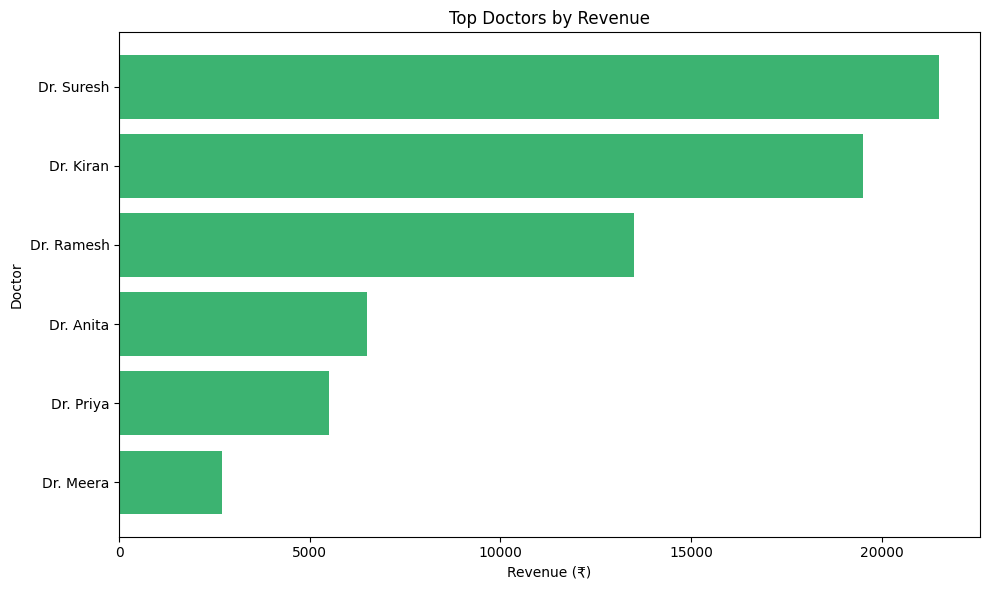

In [0]:
top_doc_pd = doctor_ranked.orderBy("revenue_rank").limit(6).toPandas()
 
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_doc_pd["doctor_name"], top_doc_pd["total_revenue"], color="mediumseagreen")
ax.set_title("Top Doctors by Revenue")
ax.set_xlabel("Revenue (₹)")
ax.set_ylabel("Doctor")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("/tmp/top_doctors_revenue.png")
display(fig)
plt.close()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


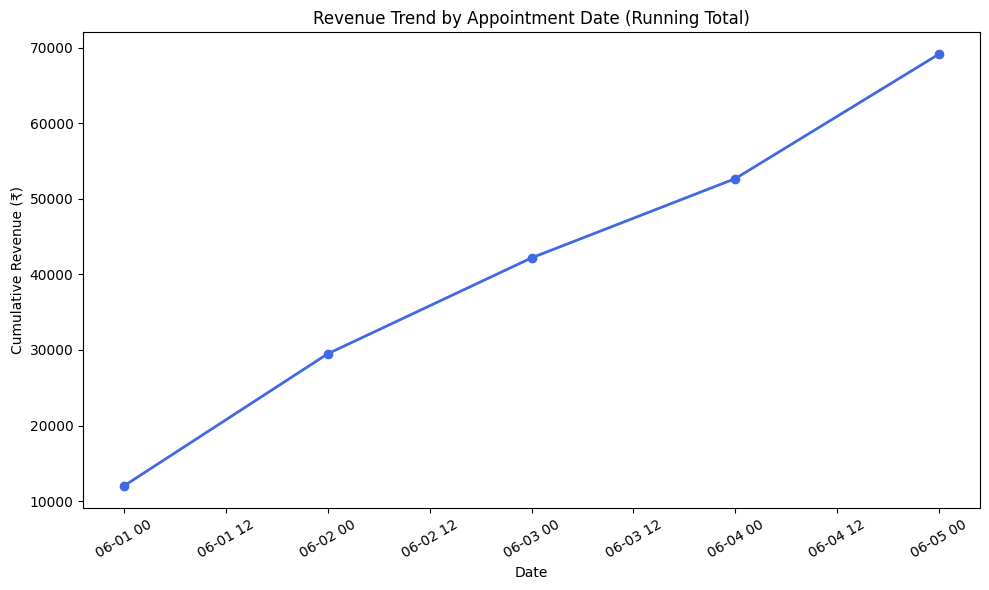

In [0]:
trend_pd = running_revenue.toPandas()
trend_pd["appointment_date"] = pd.to_datetime(trend_pd["appointment_date"])
 
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(trend_pd["appointment_date"], trend_pd["running_revenue"],
        marker="o", color="royalblue", linewidth=2)
ax.set_title("Revenue Trend by Appointment Date (Running Total)")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Revenue (₹)")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("/tmp/revenue_trend.png")
display(fig)
plt.close()

In [0]:
spark.sql("""
    CREATE TABLE IF NOT EXISTS managed_appointments
    USING DELTA
    AS SELECT * FROM silver_appointments
""")
print("Managed table 'managed_appointments' created.")

Managed table 'managed_appointments' created.


In [0]:
spark.sql("""
    CREATE TABLE IF NOT EXISTS external_appointments
    USING DELTA
    LOCATION '/Volumes/databricks_milestone/default/hospitalmanagement/'
    AS SELECT * FROM silver_appointments
""")

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|location                                                                                                                                                                                           |
+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|abfss://unity-catalog-storage@dbstorage53ivmuaqufldi.dfs.core.windows.net/7405614252828018/__unitystorage/catalogs/6af58c48-fea6-4efa-afe4-fe060d368020/tables/aee71e2e-e635-43ca-b485-63476f67f82e|
+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+

